In [318]:
import os
import torch
import json
import numpy as np
import torchvision
import cv2
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchvision.transforms as T
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

In [2]:
class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, root, annFile, transforms=None):
        self.root = root
        self.coco = COCO(annFile)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = self.coco.loadImgs(img_id)[0]['file_name']
        
        img = Image.open(os.path.join(self.root, path)).convert("RGB")

        boxes = []
        labels = []
        for ann in anns:
            xmin, ymin, w, h = ann['bbox']
            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(ann['category_id'])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            if boxes.ndim == 1:
                boxes = boxes.unsqueeze(0)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        image_id = torch.tensor([img_id])

        if boxes.shape[0] > 0:
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        else:
            area = torch.tensor([], dtype=torch.float32)

        iscrowd = torch.zeros((labels.shape[0],), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)


In [3]:
def get_transform():
    return F.to_tensor

train_dataset = CocoDataset(
    root=r'D:\Deep Learning\UAS\Second Presentation\dataset\train\images',
    annFile=r'D:\Deep Learning\UAS\Second Presentation\dataset\train\_annotations.coco.json',
    transforms=get_transform()
)

val_dataset = CocoDataset(
    root=r'D:\Deep Learning\UAS\Second Presentation\dataset\valid\images',
    annFile=r'D:\Deep Learning\UAS\Second Presentation\dataset\valid\_annotations.coco.json',
    transforms=get_transform()
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [4]:
weights_backbone = torchvision.models.ResNet50_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=weights_backbone)

num_classes = len(train_dataset.coco.getCatIds()) + 1

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if((batch_idx+1) % 100 == 0 or (batch_idx+1) % len(train_loader) == 0):
            print(f"Batch {batch_idx + 1}/{len(train_loader)} - Loss: {losses.item():.4f}")

    lr_scheduler.step()

torch.save(model.state_dict(), 'fasterrcnn_coco_custom3_30.pth')



Epoch 1/30
Batch 100/805 - Loss: 0.2570
Batch 200/805 - Loss: 0.2659
Batch 300/805 - Loss: 0.3987
Batch 400/805 - Loss: 0.3383
Batch 500/805 - Loss: 0.4192
Batch 600/805 - Loss: 0.1967
Batch 700/805 - Loss: 0.2366
Batch 800/805 - Loss: 0.1783
Batch 805/805 - Loss: 0.0891

Epoch 2/30
Batch 100/805 - Loss: 0.1072
Batch 200/805 - Loss: 0.1843
Batch 300/805 - Loss: 0.1078
Batch 400/805 - Loss: 0.1989
Batch 500/805 - Loss: 0.2370
Batch 600/805 - Loss: 0.2344
Batch 700/805 - Loss: 0.1374
Batch 800/805 - Loss: 0.1640
Batch 805/805 - Loss: 0.0978

Epoch 3/30
Batch 100/805 - Loss: 0.1534
Batch 200/805 - Loss: 0.1152
Batch 300/805 - Loss: 0.1428
Batch 400/805 - Loss: 0.1113
Batch 500/805 - Loss: 0.1432
Batch 600/805 - Loss: 0.1050
Batch 700/805 - Loss: 0.3245
Batch 800/805 - Loss: 0.0921
Batch 805/805 - Loss: 0.1277

Epoch 4/30
Batch 100/805 - Loss: 0.1518
Batch 200/805 - Loss: 0.3172
Batch 300/805 - Loss: 0.1423
Batch 400/805 - Loss: 0.2864
Batch 500/805 - Loss: 0.2476
Batch 600/805 - Loss: 0.

In [3]:
CLASS_NAMES = ['','Bomb', 'Fire', 'Hand Gun', 'Knife', 'Rifle', 'Smoke'] 

def predict_and_show(model, image_input, threshold=0.75):
    if isinstance(image_input, np.ndarray):
        img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB)).convert("RGB")
    else:
        img = Image.open(image_input).convert("RGB")

    img_tensor = F.to_tensor(img).to(device)

    model.eval()
    with torch.no_grad():
        prediction = model([img_tensor])[0]

    
    plt.figure(figsize=(8, 8)) 
    plt.imshow(img)
    ax = plt.gca()

    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        if score >= threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            class_name = CLASS_NAMES[label] if label < len(CLASS_NAMES) else str(label)

            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 fill=False, color='lime', linewidth=3)
            ax.add_patch(rect)

            ax.text(x1, y1 - 5, f'{class_name}: {score:.2f}', color='black',
                    bbox=dict(facecolor='yellow', alpha=0.7), fontsize=12)

    plt.axis('off')
    plt.tight_layout()
    plt.show()


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!


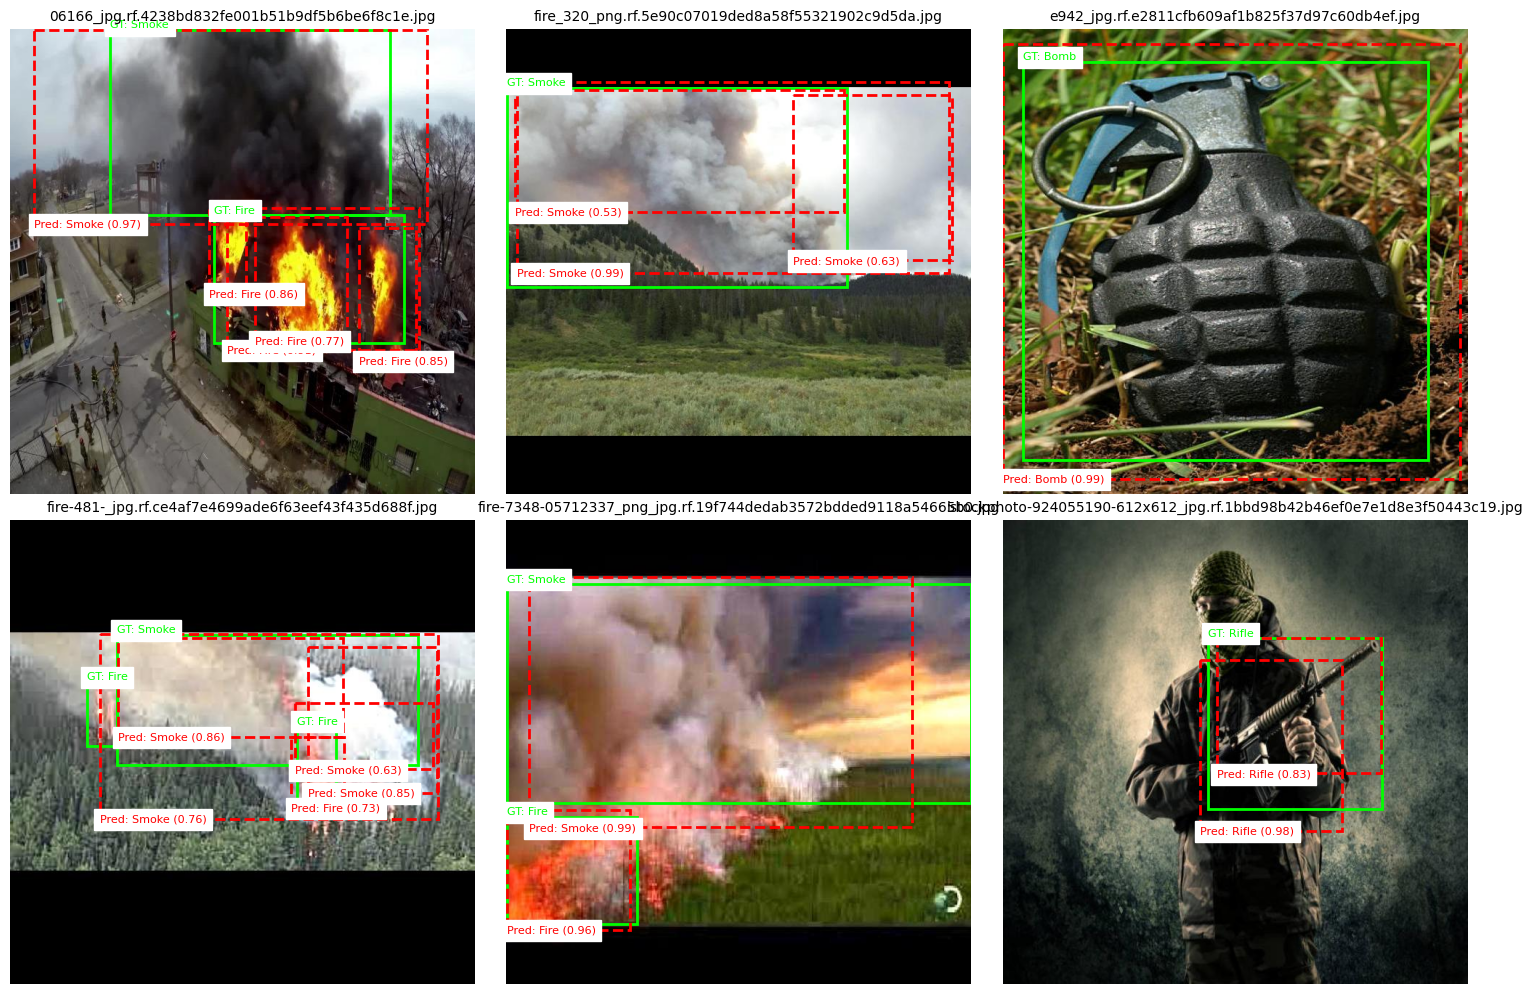

In [315]:
image_dir = r"D:\Deep Learning\UAS\Second Presentation\dataset\test\images"
gt_json = r"D:\Deep Learning\UAS\Second Presentation\dataset\test\_annotations.coco.json"
pred_json = r"D:\Deep Learning\UAS\Second Presentation\results.json"

coco_gt = COCO(gt_json)
coco_dt = coco_gt.loadRes(pred_json)

num_images = 6
img_ids = coco_gt.getImgIds()
selected_img_ids = random.sample(img_ids, num_images)

cols = 3
rows = (num_images + cols - 1) // cols

gt_color = 'lime'
pred_color = 'red'

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()  

for idx, img_id in enumerate(selected_img_ids):
    img_info = coco_gt.loadImgs(img_id)[0]
    img_path = os.path.join(image_dir, img_info['file_name'])
    image = plt.imread(img_path)

    anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=img_id))
    dets = coco_dt.loadAnns(coco_dt.getAnnIds(imgIds=img_id))

    ax = axes[idx]
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(img_info['file_name'], fontsize=10)

    for ann in anns:
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=gt_color, facecolor='none')
        ax.add_patch(rect)
        cat_name = coco_gt.loadCats(ann['category_id'])[0]['name']
        ax.text(x, y - 2, f"GT: {cat_name}", color=gt_color, fontsize=8, backgroundcolor='white')

    for det in dets:
        x, y, w, h = det['bbox']
        score = det.get('score', 0)
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=pred_color, facecolor='none', linestyle='--')
        ax.add_patch(rect)
        cat_name = coco_gt.loadCats(det['category_id'])[0]['name']
        ax.text(x, y + h + 5, f"Pred: {cat_name} ({score:.2f})", color=pred_color, fontsize=8, backgroundcolor='white')

for j in range(len(selected_img_ids), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


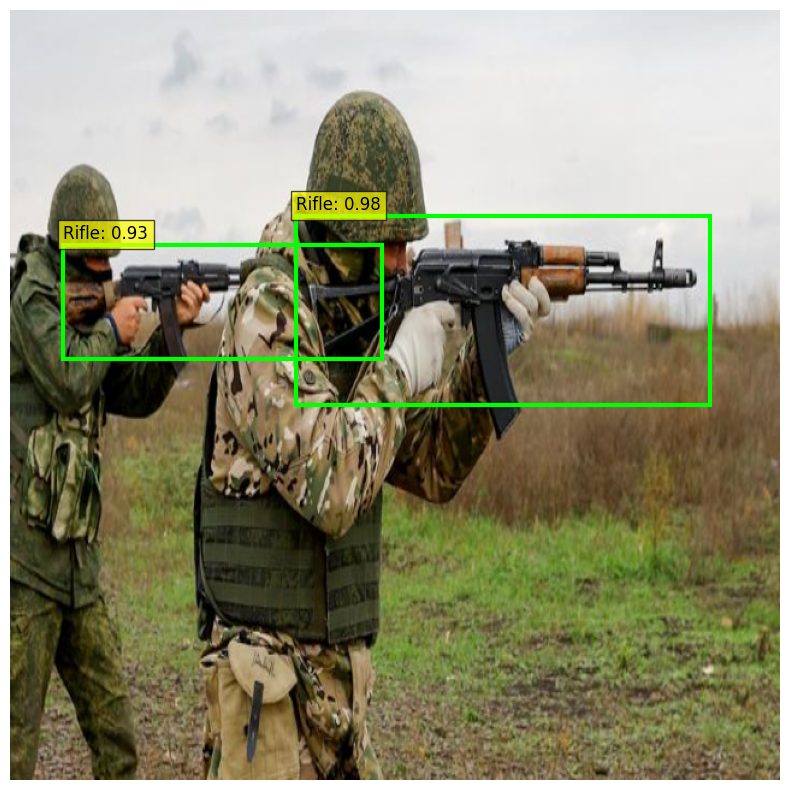

In [50]:
model.load_state_dict(torch.load(r'D:\Deep Learning\UAS\Second Presentation\fasterrcnn_coco_custom3_30.pth'))
device = torch.device('cpu')
model.to(device)
model.eval()

image_path = r"D:\Deep Learning\UAS\Second Presentation\1147834_720.jpg"
image = cv2.imread(image_path)
resized = cv2.resize(image, (640, 640))
predict_and_show(model, resized)

In [ ]:
def predict_and_draw(model, image):
    transform = T.Compose([
        T.ToTensor(),
    ])
    img_tensor = transform(image).to(device)

    with torch.no_grad():
        outputs = model([img_tensor])
    
    output = outputs[0]

    boxes = output['boxes'].cpu().numpy()
    scores = output['scores'].cpu().numpy()
    labels = output['labels'].cpu().numpy()

    threshold = 0.5
    for box, score, label in zip(boxes, scores, labels):
        if score > threshold:
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, f"{label}:{score:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return image

video_path = r"D:\Deep Learning\UAS\Second Presentation\clideo_editor_ddfe959f4c6a471f87b34cdb90fd9af4.mp4"
cap = cv2.VideoCapture(video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_path = r"D:\Deep Learning\UAS\Second Presentation\output.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (640, 640))  

while True:
    ret, frame = cap.read()
    if not ret:
        break

    resized = cv2.resize(frame, (640, 640))

    result_frame = predict_and_draw(model, resized)

    out.write(result_frame)

cap.release()
out.release()

In [13]:
test_dataset = CocoDataset(
    root=r'D:\Deep Learning\UAS\Second Presentation\dataset\test\images',
    annFile=r'D:\Deep Learning\UAS\Second Presentation\dataset\test\_annotations.coco.json',
    transforms=get_transform()
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

score_threshold = 0.5
results = []

for images, targets in tqdm(test_loader):
    images = [img.to(device) for img in images]
    outputs = model(images)

    for target, output in zip(targets, outputs):
        boxes = output['boxes'].detach().cpu().numpy()
        scores = output['scores'].detach().cpu().numpy()
        labels = output['labels'].detach().cpu().numpy()
        image_id = int(target['image_id'].item())

        for box, score, label in zip(boxes, scores, labels):
            if score < score_threshold:
                continue
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            results.append({
                "image_id": int(image_id),
                "category_id": int(label),
                "bbox": [float(x_min), float(y_min), float(width), float(height)],
                "score": float(score)
            })

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 202/202 [05:28<00:00,  1.63s/it]


In [305]:
coco_gt = COCO(r'D:\Deep Learning\UAS\Second Presentation\dataset\test\_annotations.coco.json')
coco_dt = coco_gt.loadRes(r'D:\Deep Learning\UAS\Second Presentation\results.json')

coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.410
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.811
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.352
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.100
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.431
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.414
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.527
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [309]:
area_medium = 2
area_large = 3

map50 = coco_eval.stats[1] 
print(f"\nmAP@50: {map50 * 100:.2f}%")

precision = coco_eval.eval['precision']
prec_iou50_area = precision[0, :, :, area_medium, 2]  
prec_valid = prec_iou50_area[prec_iou50_area > -1]
mean_precision = np.mean(prec_valid)
print(f"Precision (medium): {mean_precision * 100:.2f}%")
prec_iou50_area = precision[0, :, :, area_large, 2]  
prec_valid = prec_iou50_area[prec_iou50_area > -1]
mean_precision = np.mean(prec_valid)
print(f"Precision (large): {mean_precision * 100:.2f}%")

recall = coco_eval.eval['recall']
recall_iou50_area = recall[0, :, area_medium, 2]  
recall_valid = recall_iou50_area[recall_iou50_area > -1]
mean_recall = np.mean(recall_valid)
print(f"Recall (medium): {mean_recall * 100:.2f}%")
recall_iou50_area = recall[0, :, area_large, 2]  
recall_valid = recall_iou50_area[recall_iou50_area > -1]
mean_recall = np.mean(recall_valid)
print(f"Recall (large): {mean_recall * 100:.2f}%")



mAP@50: 81.10%
Precision (medium): 53.36%
Precision (large): 83.19%
Recall (medium): 57.78%
Recall (large): 89.40%


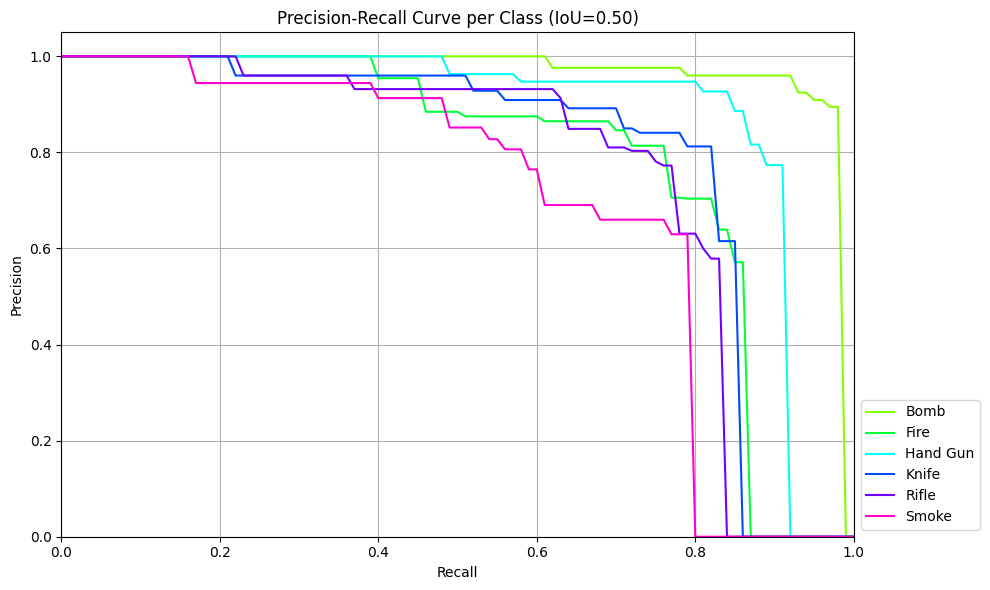

In [317]:
precisions = coco_eval.eval['precision']  
recalls = coco_eval.params.recThrs         
cats = coco_gt.loadCats(coco_gt.getCatIds())
cat_names = [cat['name'] for cat in cats]

area_idx = 0
maxdet_idx = 2
iou_idx = 0 

colors = sns.color_palette("hsv", len(cat_names))

plt.figure(figsize=(10, 6))
for cls_idx, cls_name in enumerate(cat_names):
    pr = precisions[iou_idx, :, cls_idx, area_idx, maxdet_idx]  
    if np.all(pr == -1): 
        continue
    plt.plot(recalls, pr, label=cls_name, color=colors[cls_idx])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve per Class (IoU=0.50)")
plt.grid(True)
plt.legend(loc="lower left", bbox_to_anchor=(1, 0))
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()


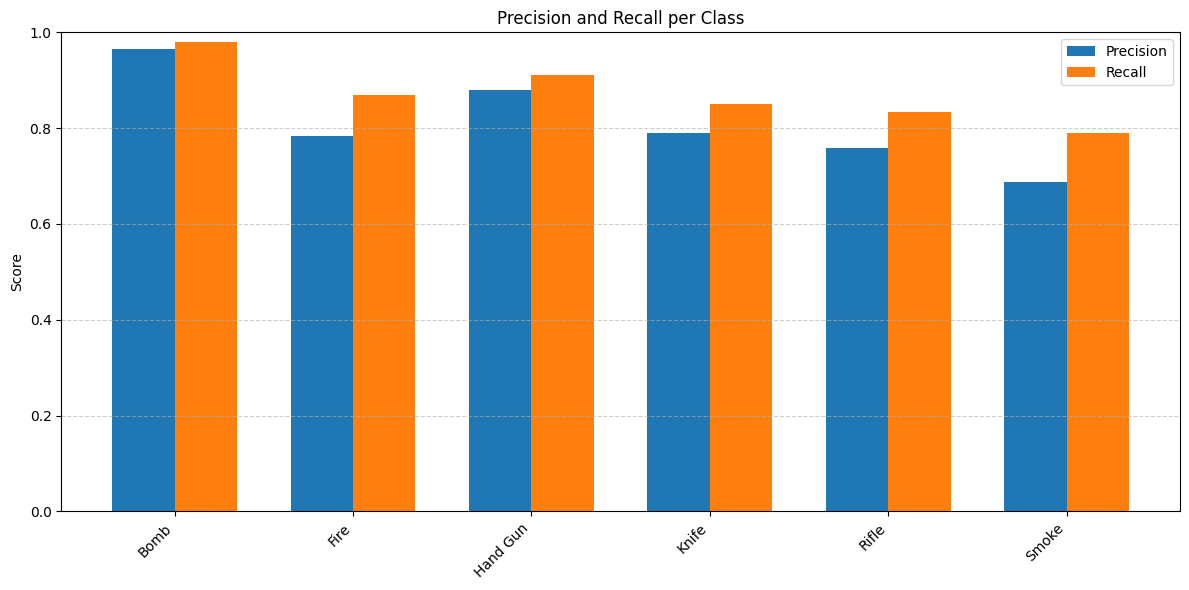

In [310]:
cats = coco_gt.loadCats(coco_gt.getCatIds())
cat_names = [cat['name'] for cat in cats]
precisions = coco_eval.eval['precision']
recalls = coco_eval.eval['recall']

ap_per_class = []
recall_per_class = []
filtered_cat_names = []

for i, name in enumerate(cat_names):
    if name.lower() == "objects":
        continue

    precision = precisions[0, :, i, 0, 2] 
    precision = precision[precision > -1]
    ap = np.mean(precision) if precision.size else float('nan')

    recall = recalls[0, i, 0, 2] 

    ap_per_class.append(ap)
    recall_per_class.append(recall)
    filtered_cat_names.append(name)

x = np.arange(len(filtered_cat_names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, ap_per_class, width, label='Precision')
plt.bar(x + width/2, recall_per_class, width, label='Recall')

plt.title("Precision and Recall per Class")
plt.ylabel("Score")
plt.xticks(x, filtered_cat_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
